In [1]:
from skimage.io import imread
import numpy as np
from scipy.io import loadmat
from matplotlib import pyplot as plt

In [2]:
rootfolder = '..'

IRLS Algorithm
--------------
Define the problem parameters


In [3]:
A = np.array([[1, 3], [3, 1]]) # low dimensions to plot it, you can test larger sizes
b = np.array([-1, 2])

lmbda = 0.5

The function to be minimized is $\frac{1}{2}\|Ax-b\|_2^2 + \lambda \|x\|_1$

In [4]:
f = lambda x: 0.5 * np.sum((A @ x - b) ** 2) + lmbda * np.sum(np.abs(x))

# gradient of the smooth data-fitting term: 1/2 ||Ax-b||_2^2
df = lambda x: A.T @ (A @ x) - A.T @ b

Plot the function

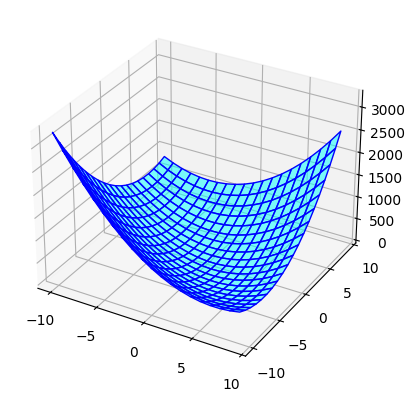

In [5]:
# this function has been prepared only for the visualization sake, no need to go through this but it renders some nice graphics :)
F = lambda r1, r2: (r1 * A[0, 0] + r2 * A[0, 1] - b[0]) ** 2 + (r1 * A[1, 0] + r2 * A[1,1] - b[1]) ** 2 + lmbda * (np.abs(r1) + np.abs(r2))
xx, yy = np.meshgrid(np.arange(-10, 10, 1), np.arange(-10, 10, 1))

fig = plt.figure()
ax = plt.axes(projection='3d')
ax.plot_surface(xx, yy, F(xx, yy), edgecolor=[0, 0, 1], alpha=0.5, facecolor=[0, 1, 1])

Set the parameters

In [6]:
MAX_ITER = 1000
TOL_DIST_X = 1e-10

Initialization: test different inizializations, the function is convex, you always converge to the same solution

In [7]:
x0 = np.array([5, -10])

# initialization
all_x = [x0]
distanceX = 1e10  # stopping criteria
cnt = 0
delta = 1e-6

Main loop

In [8]:
while cnt < MAX_ITER and distanceX > TOL_DIST_X:
    x = all_x[-1]

    # compute the reweighting matrix
    W = np.diag(1 / (delta + np.abs(x)))

    # solve the weighted regularized LS system
    # x_current = np.linalg.inv(A.T @ A + lmbda * W) @ A.T @ b
    x_current = np.linalg.solve(A.T @ A + lmbda * W, A.T @ b) # more efficient

    distanceX = np.linalg.norm(x_current - x)

    # store the estimate
    all_x.append(x_current)

    cnt = cnt + 1

Plot all the estimates

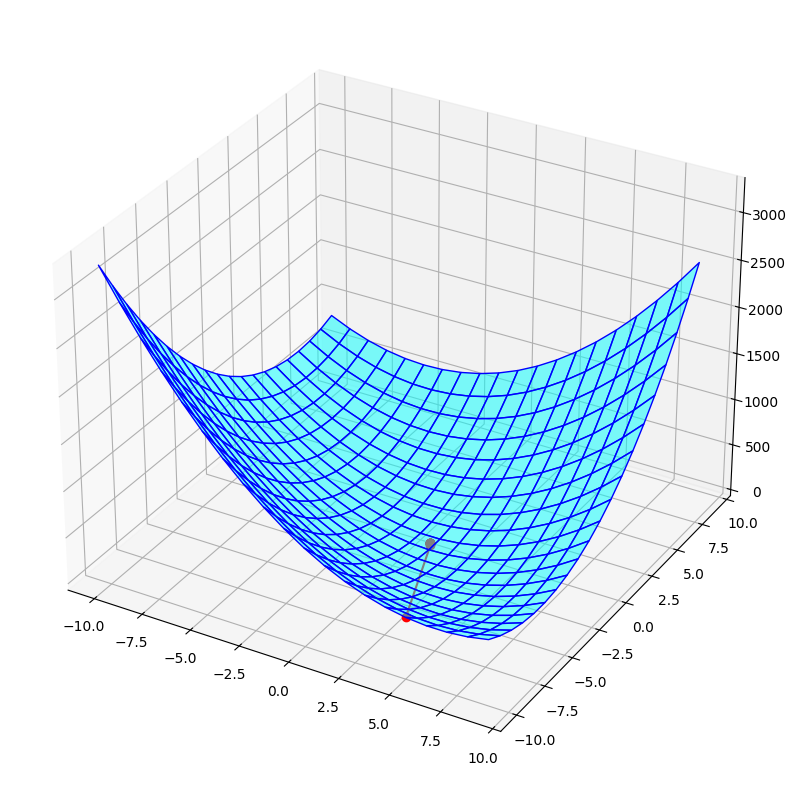

In [9]:
# plot the new estimate
xxplot = [x[0] for x in all_x]
yyplot = [x[1] for x in all_x]
zzplot = F(np.array(xxplot), np.array(yyplot))

fig = plt.figure(figsize=(10,10))
ax = plt.axes(projection='3d')
ax.plot_surface(xx, yy, F(xx, yy), edgecolor=[0, 0, 1], alpha=0.5, facecolor=[0, 1, 1])
ax.plot3D(xxplot, yyplot, zzplot, 'r-o')

In [10]:
print(f'nr of iteration of IRLS (before stopping criteria met): {cnt}\n')
print(f'Solution of IRLS: [{x_current[0]:.4f}, {x_current[1]:.4f}]\n')
print(f'Value of the functional: {f(x_current):.4f}\n')

nr of iteration of IRLS (before stopping criteria met): 14

Solution of IRLS: [0.7500, -0.5000]

Value of the functional: 0.6875



MOD dictionary learning
-----------------------
Useful function for plot the 2D DCT dictionary

In [9]:
def get_dictionary_img(D):
    M, N = D.shape
    p = int(round(np.sqrt(M)))
    nnn = int(np.ceil(np.sqrt(N)))
    bound = 2
    img = np.ones((nnn*p+bound*(nnn-1), nnn*p+bound*(nnn-1)))
    for i in range(N):
        m = np.mod(i, nnn)
        n = int((i-m)/nnn)
        m = m * p + bound * m
        n = n * p + bound * n
        atom = D[:, i].reshape((p, p))
        if atom.min() < atom.max():
            atom = (atom - atom.min()) / (atom.max() - atom.min())
        img[m: m + p, n: n + p] = atom

    return img

Define a function to perform the sparse coding using your favorite algorithm (IRLS, FISTA or ISTA)

In [10]:
# In MOD, sparse coding is called many times, so we only keep the latest estimate instead of storing the full history

def ISTA(s, D, lmbda, x0=None, MAX_ITER=1000, TOL_DIST_X=1e-10, alpha=None):
    if x0 is None:
        x = np.ones(D.shape[1])
    else:
        x = x0.copy()

    # initialize stopping criterion and iteration counter
    distanceX = 1e10
    cnt = 0

    # precompute constant matrices/vectors
    DtD = D.T @ D
    Dts = D.T @ s
    
    # compute step size if not provided
    if alpha is None:
        L = np.max(np.linalg.eigvalsh(DtD))
        alpha = 1 / L
    
    # gradient of the smooth term 1/2 ||D x - s||_2^2
    df = lambda x: DtD @ x - Dts

    while cnt < MAX_ITER and distanceX > TOL_DIST_X:
        # compute the argument of the proximal operator
        x_gd = x - alpha * df(x)

        # perform soft thresholding
        x_current = np.sign(x_gd) * np.maximum(np.abs(x_gd) - alpha * lmbda, 0.0)

        # compute the distance between two consecutive iterates for stopping criterion
        distanceX = np.linalg.norm(x_current - x)

        # update the current estimate
        x = x_current

        cnt += 1

    return x

def FISTA(s, D, lmbda, x0=None, MAX_ITER=1000, TOL_DIST_X=1e-10, gamma=None):
    if x0 is None:
        x = np.ones(D.shape[1])
    else:
        x = x0.copy()

    # initialize extrapolated point
    y = x.copy()

    # initialize FISTA momentum parameter
    t = 1.0

    # initialize stopping criterion and iteration counter
    distanceX = 1e10
    cnt = 0

    # precompute constant matrices/vectors
    DtD = D.T @ D
    Dts = D.T @ s

    # compute step size if not provided
    if gamma is None:
        gamma = 1 / np.max(np.linalg.eigvalsh(DtD))
        
    # gradient of the smooth term 1/2 ||D x - s||_2^2
    df = lambda x: DtD @ x - Dts

    while cnt < MAX_ITER and distanceX > TOL_DIST_X:
        # store previous estimate
        x_old = x.copy()

        # compute the argument of the proximal operator from the extrapolated point
        x_gd = y - gamma * df(y)

        # perform soft thresholding
        x_current = np.sign(x_gd) * np.maximum(np.abs(x_gd) - gamma * lmbda, 0.0)

        # update FISTA momentum parameter
        t_current = (1 + np.sqrt(1 + 4 * t**2)) / 2

        # update extrapolated point
        y = x_current + ((t - 1) / t_current) * (x_current - x_old)

        # compute the distance between two consecutive iterates for stopping criterion
        distanceX = np.linalg.norm(x_current - x_old)

        # update current estimate and momentum parameter
        x = x_current
        t = t_current

        cnt += 1

    return x

def IRLS(s, D, lmbda, x0=None, MAX_ITER=1000, TOL_DIST_X=1e-10, delta=1e-6):
    if x0 is None:
        x = np.ones(D.shape[1])
    else:
        x = x0.copy()

    # initialize stopping criterion and iteration counter
    distanceX = 1e10
    cnt = 0

    # precompute constant matrices/vectors
    DtD = D.T @ D
    Dts = D.T @ s

    while cnt < MAX_ITER and distanceX > TOL_DIST_X:
        # compute the reweighting matrix from the current estimate
        W = np.diag(1 / (delta + np.abs(x)))

        # solve the weighted regularized LS system
        x_current = np.linalg.solve(DtD + lmbda * W, Dts)

        # compute the distance between two consecutive iterates for stopping criterion
        distanceX = np.linalg.norm(x_current - x)

        # update the current estimate
        x = x_current

        cnt += 1
    
    return x

Load the image and rescale it in [0,1]

In [11]:
path_image = f'{rootfolder}/data/barbara.png'
img = imread(path_image) / 255

imsz = img.shape

Set the parameters

In [12]:
# patch size
p = 8

# number of elements in the patchfrom skimage.io import imread
M = p ** 2

# number of columns in the dictionary
N = 96

# extract the random patches from the noisy image
npatch = 1000

# only few MOD iterations are needed for a good dictionary
max_iter = 10

lmbda = 0.1

Extract $npatch$ random patches from the image


In [13]:
S = np.zeros((M, npatch))

for i in range(npatch):
    x = np.random.randint(0, imsz[0] - p + 1)
    y = np.random.randint(0, imsz[1] - p + 1)
    patch = img[x : x+p, y : y+p].flatten()
    S[:, i] = patch

Initialize the dictionary randomly and the normalize the columns

In [14]:
D = np.random.randn(M, N)
D = D / np.linalg.norm(D, axis=0, keepdims=True)

Initialize a matrix for the coefficients of all the patches

In [15]:
X = np.zeros((N, npatch))

Main loop

In [18]:
for iter in range(max_iter):
    # perform the sparse coding for all the patches in S
    for n in range(npatch):
        s = S[:, n]
        # ISTA sparse coding
        # x = ISTA(s, D, lmbda)
        
        # FISTA sparse coding
        # x = FISTA(s, D, lmbda)
        
        # IRLS sparse coding
        x = IRLS(s, D, lmbda)
        
        X[:, n] = x

    # MOD update
    D = (S @ X.T) @ np.linalg.inv(X @ X.T + 1e-6 * np.eye(N))

    # normalize the column
    D = D / np.linalg.norm(D, axis=0, keepdims=True)

Show the dictionary

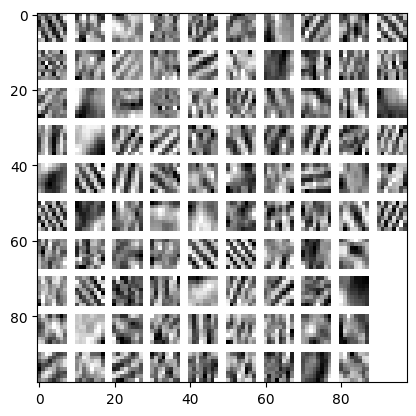

In [19]:
img_dict = get_dictionary_img(D)
plt.figure()
plt.imshow(img_dict, cmap='gray')

Denoising via $\ell^1$ sparse coding (you can use either the dictionary learned by KSVD or MOD)
------------------------------------
Set the noise level and add the noise to the original image

In [16]:
sigma_noise = 20/255
noisy_img = img + np.random.normal(size=imsz) * sigma_noise

Compue the psnr of the noisy input

In [17]:
psnr_noisy = 10 * np.log10(1 / np.mean((img - noisy_img)**2))

Text(0.5, 1.0, 'Noisy image, PSNR = 22.12')

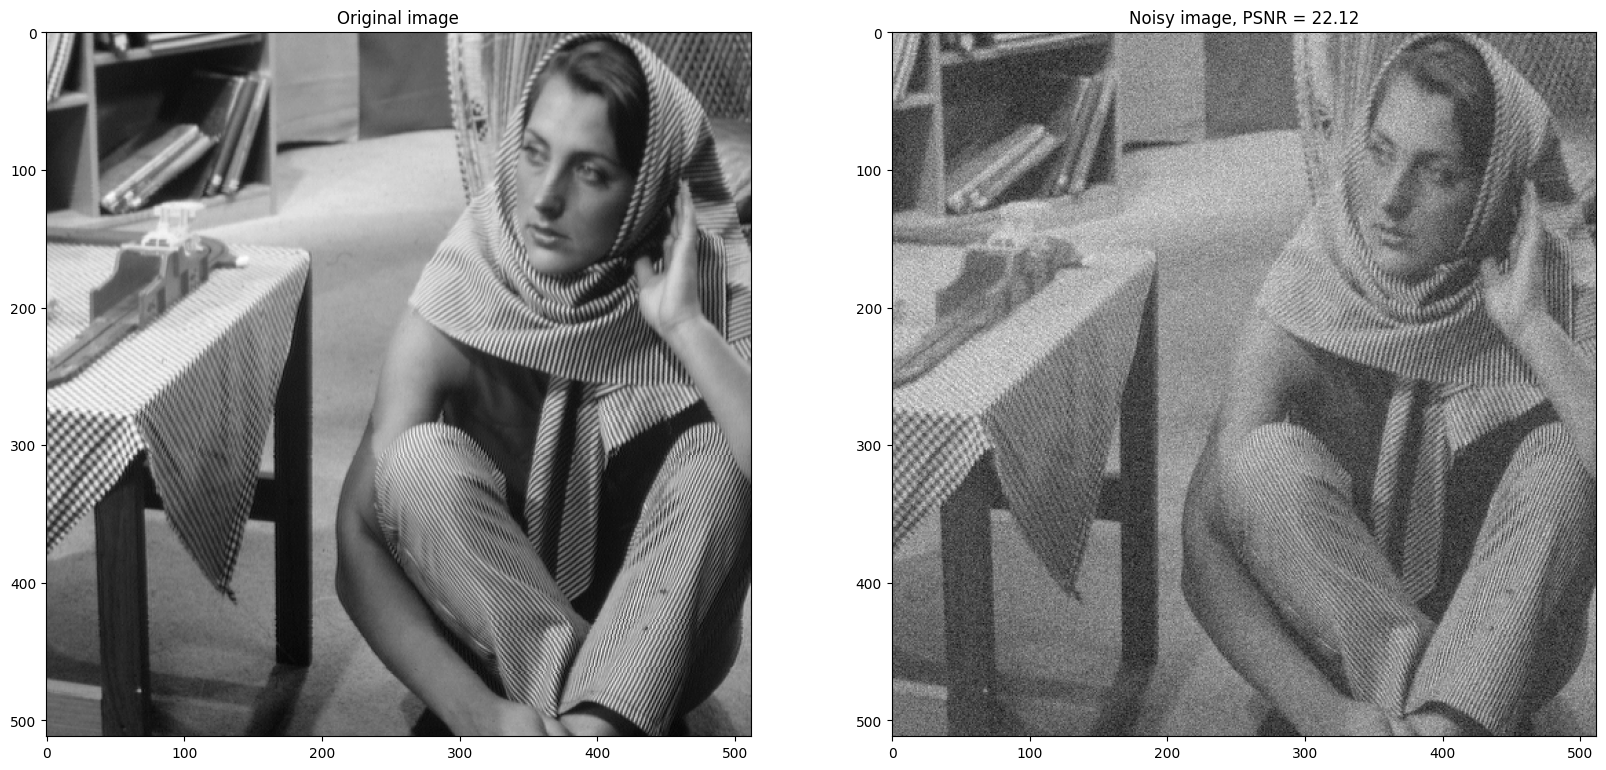

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
ax[0].imshow(img, cmap='gray')
ax[0].set_title('Original image')

ax[1].imshow(noisy_img, cmap='gray')
ax[1].set_title(f'Noisy image, PSNR = {psnr_noisy:.2f}')

Load a pretrained dictionary $D$

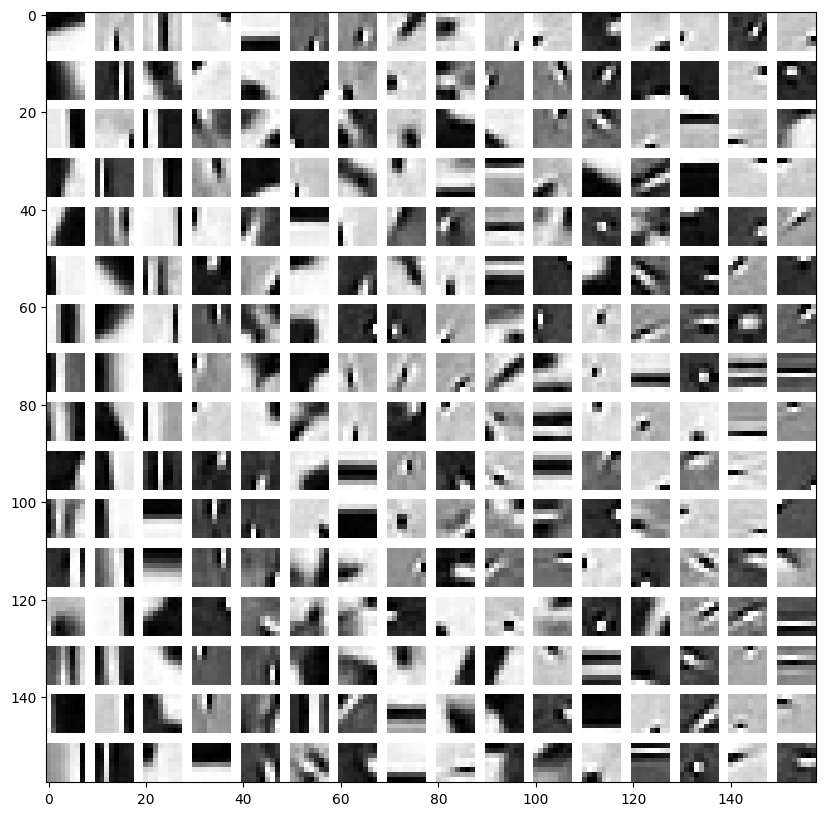

In [18]:
D = loadmat(f'{rootfolder}/data/dict_nat_img.mat')['D']

# show the dictionary
D_img = get_dictionary_img(D)
plt.figure(figsize=(10,10))
plt.imshow(D_img, cmap='gray')

In [28]:
# initialize the estimated image
img_hat_FISTA = np.zeros_like(img)

# initialize the weight matrix
weights_FISTA = np.zeros_like(img)

# set the threshold
tau = 2.2
lmbda = tau * sigma_noise

# define the step (=p for non overlapping paches)
STEP = 4 # STEP = 1 might be very time consuming, start with larger STEP

Operate patchwise, use FISTA to perform the Sparse Coding step.

In [25]:
for i in range(0, imsz[0] - p + 1, STEP):
    for j in range(0, imsz[1] - p + 1, STEP):
        # extrach the patch with the top left corner at pixel (ii, jj)
        s = noisy_img[i : i+p, j : j+p].flatten()

        # store and subtract the mean
        s_mean = np.mean(s)
        s = s - s_mean

        # perform the sparse coding of the patch s to compute the coefficients vector x
        x = FISTA(s, D, lmbda)
        
        # perform the reconstruction
        s_hat = D @ x

        w = 1

        # add back the mean
        s_hat = s_hat + s_mean

        # put the denoised patch into the estimated image using uniform weights
        img_hat_FISTA[i : i+p, j : j+p] += w * s_hat.reshape((p, p))

        # store the weight of the current patch in the weight matrix
        weights_FISTA[i : i+p, j : j+p] += w

Normalize the estimated image with the computed weights

In [26]:
img_hat_FISTA = img_hat_FISTA / weights_FISTA

Compute the psnr of the estimated image

Text(0.5, 1.0, 'Estimated Image,\nPSNR = 27.02')

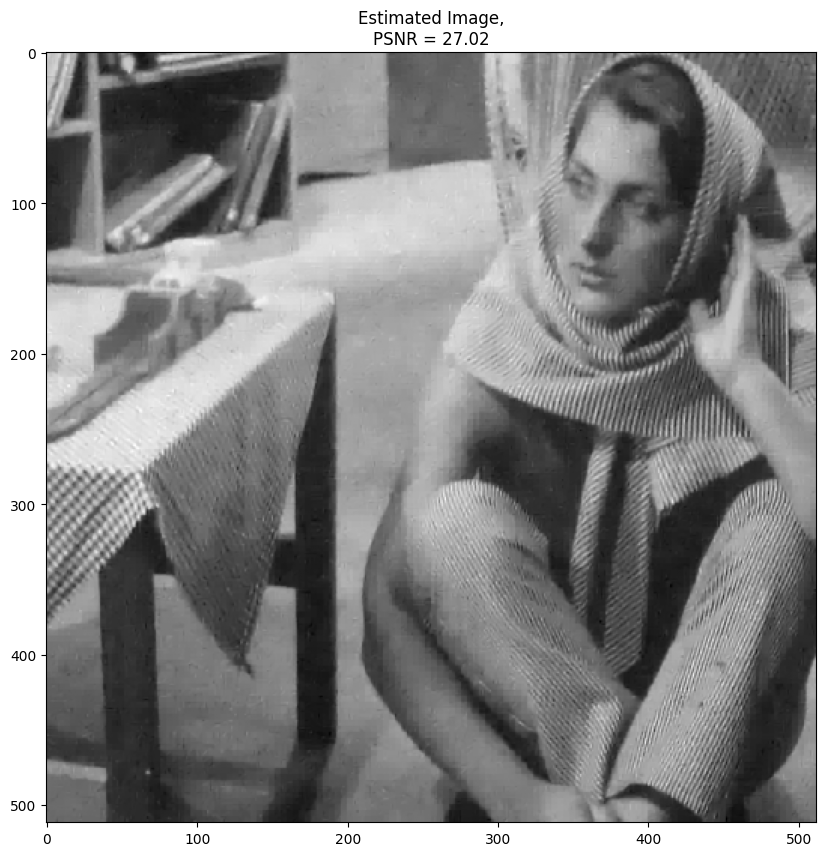

In [27]:
psnr_hat_FISTA = 10 * np.log10(1 / np.mean((img - img_hat_FISTA) ** 2))
plt.figure(figsize=(10,10))
plt.imshow(img_hat_FISTA, cmap='gray')
plt.title(f'Estimated Image,\nPSNR = {psnr_hat_FISTA:.2f}')

Repeat the same process, but this time replace FISTA with IRLS and compare the denoised images.

In [19]:
# initialize the estimated image
img_hat_IRLS = np.zeros_like(img)

# initialize the weight matrix
weights_IRLS = np.zeros_like(img)

In [30]:
for i in range(0, imsz[0] - p + 1, STEP):
    for j in range(0, imsz[1] - p + 1, STEP):
        # extrach the patch with the top left corner at pixel (ii, jj)
        s = noisy_img[i : i+p, j : j+p].flatten()

        # store and subtract the mean
        s_mean = np.mean(s)
        s = s - s_mean

        # perform the sparse coding of the patch s to compute the coefficients vector x
        x = IRLS(s, D, lmbda)
        
        # perform the reconstruction
        s_hat = D @ x

        w = 1

        # add back the mean
        s_hat = s_hat + s_mean

        # put the denoised patch into the estimated image using uniform weights
        img_hat_IRLS[i : i+p, j : j+p] += w * s_hat.reshape((p, p))

        # store the weight of the current patch in the weight matrix
        weights_IRLS[i : i+p, j : j+p] += w

Normalize the estimated image with the computed weights

In [31]:
img_hat_IRLS = img_hat_IRLS / weights_IRLS

Compute the psnr of the estimated image

Text(0.5, 1.0, 'Estimated Image,\nPSNR = 27.04')

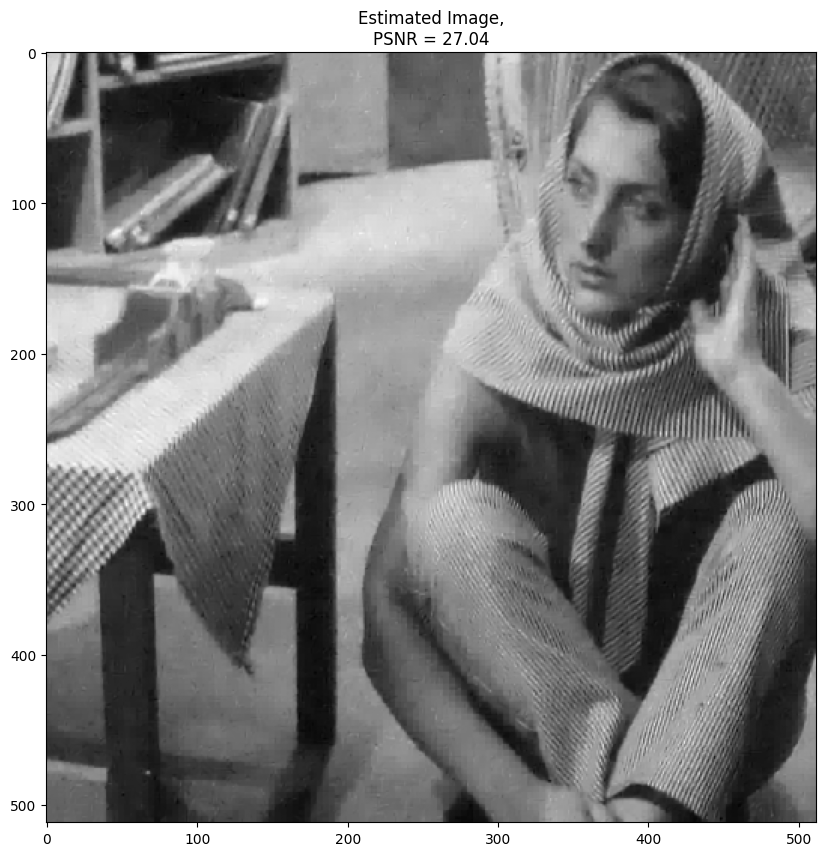

In [32]:
psnr_hat_IRLS = 10 * np.log10(1 / np.mean((img - img_hat_IRLS) ** 2))
plt.figure(figsize=(10,10))
plt.imshow(img_hat_IRLS, cmap='gray')
plt.title(f'Estimated Image,\nPSNR = {psnr_hat_IRLS:.2f}')